# Experiment 2 

Each of the 20 free parameters is varied in isolation while the rest are held at
a fixed baseline.

In [ ]:
import json
import math
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np
from matplotlib.animation import FuncAnimation, FFMpegWriter
import animate_model as am

import analysis
import plots
from experiment_config import (
    PARAM_GROUPS,
    PRIMARY_BASELINE,
    PRIMARY_SWEEP_TASK,
    SEED_SETS,
    SENSITIVITY_METRICS,
    SWEEP_BASELINES,
    SWEEP_CONFIG,
    SWEEP_TASKS,
    SWEEP_TRIALS_PER_SEED_SET,
)
from model_utils import TaskConfig
from planning_cascade_model import run_trial

In [ ]:
RESULTS = Path("results")
BASELINE = SWEEP_BASELINES[PRIMARY_BASELINE]
TASK = SWEEP_TASKS[PRIMARY_SWEEP_TASK]
cwd = Path.cwd()

for name, task in SWEEP_TASKS.items():
    print(
        f"{name:22s} goal=({task.goal_x:.2f}, {task.goal_y:.2f}, "
        f"{math.degrees(task.goal_angle):.0f} deg)  "
        f"object {task.obj_width:.2f} x {task.obj_height:.2f}  limit {task.max_timesteps}"
    )
print()

for name, baseline in SWEEP_BASELINES.items():
    print(
        f"{name:10s} horizon {baseline.planning_horizon}  "
        f"threshold {baseline.initiation_threshold:.2f}  "
        f"sampling {baseline.sampling_rate:.2f}  wm {baseline.wm_capacity}"
    )

print(f"\nprimary: baseline '{PRIMARY_BASELINE}' on task '{PRIMARY_SWEEP_TASK}'")

hard_balanced          goal=(0.90, 0.00, 135 deg)  object 0.60 x 0.30  limit 180
translation_dominant   goal=(1.10, 0.00, 11 deg)  object 0.40 x 0.40  limit 180
rotation_dominant      goal=(0.35, 0.00, 135 deg)  object 0.60 x 0.30  limit 180

immature   horizon 2  threshold 0.22  sampling 0.40  wm 2
mid        horizon 3  threshold 0.28  sampling 0.55  wm 3
mature     horizon 5  threshold 0.42  sampling 0.75  wm 4

primary: baseline 'mid' on task 'hard_balanced'


## Load results

Run `python run_experiments.py --only exp2` first if not done the whole thing yet.

In [ ]:
with open(RESULTS / "experiment_2.json") as handle:
    exp2 = json.load(handle)

sweep_data = {
    parameter: {
        float(value) if "." in value or "e" in value.lower() else int(value): summary
        for value, summary in by_value.items()
    }
    for parameter, by_value in exp2["primary"].items()
}
index = exp2["primary_index"]
sorted_params = index["order"]

for by_value in sweep_data.values():
    for summary in by_value.values():
        summary["mean_object_fixation"] = 1.0 - summary["mean_target_fixation"]

print("conditions:", sum(len(v) for v in sweep_data.values()))

conditions: 138


## Sensitivity heatmap

parameter                  mean Success r Path effi Pos error Angle err Movement  Gaze swit Target fi Trans bef
planning_horizon          0.608     1.000     1.000     1.000     1.000     0.033     0.617     0.210     0.000
correction_rate           0.497     0.950     0.763     0.702     0.734     0.018     0.517     0.041     0.250
initiation_threshold      0.459     0.220     0.372     0.119     0.654     1.000     0.253     0.057     1.000
sampling_rate             0.394     0.330     0.646     0.281     0.744     0.846     0.272     0.034     0.000
affordance_coupling       0.327     0.740     0.546     0.441     0.457     0.019     0.359     0.053     0.000
wm_capacity               0.261     0.260     0.427     0.240     0.549     0.394     0.171     0.048     0.000
target_bias               0.241     0.250     0.204     0.168     0.105     0.120     0.079     1.000     0.000
gaze_switch_rate          0.203     0.180     0.131     0.093     0.102     0.024     1.000     0.093   

/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74898/1428901479.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_sensitivity_heatmap(index, sweep_data).show()


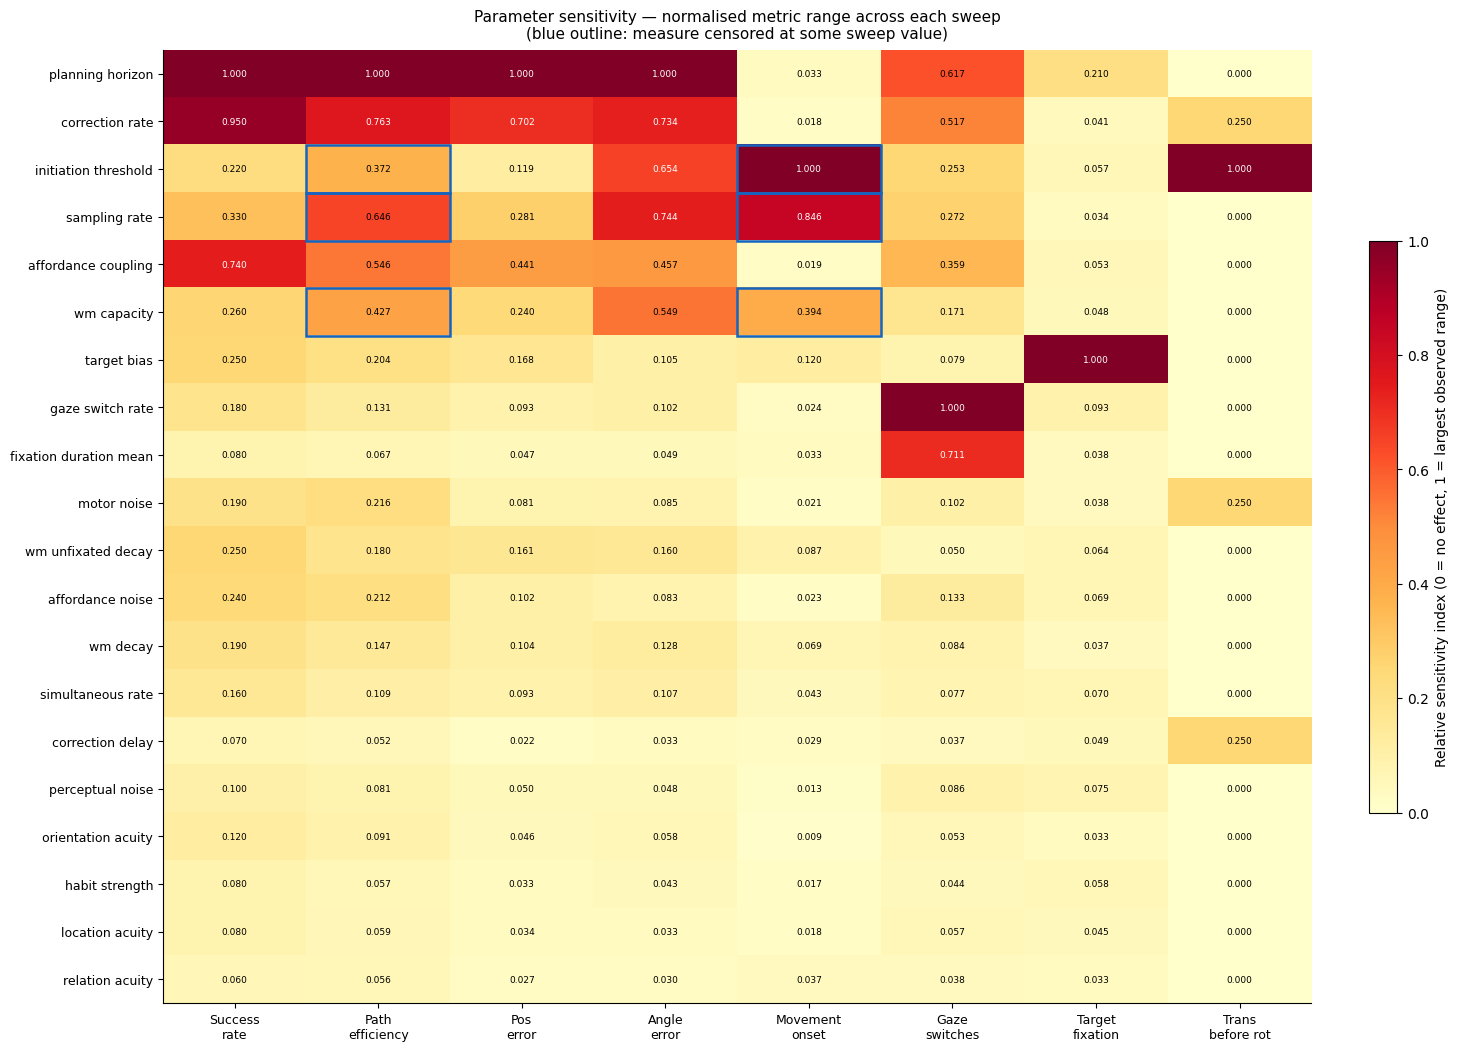

In [ ]:
plots.plot_sensitivity_heatmap(index, sweep_data).show()

print(
    f"{'parameter':24s}{'mean':>7s}"
    + "".join(
        f"{label.replace(chr(10), ' ')[:9]:>10s}" for _, label in SENSITIVITY_METRICS
    )
)

for parameter in sorted_params:
    print(
        f"{parameter:24s}{index['mean_index'][parameter]:7.3f}"
        + "".join(
            f"{index['normalised'][parameter][key]:10.3f}"
            for key, _ in SENSITIVITY_METRICS
        )
    )

## Censoring at high initiation thresholds

In [ ]:
print(f"{'threshold':>10s}{'no onset':>10s}{'onset|moved':>13s}{'path eff|moved':>16s}{'success':>9s}")

for value in sorted(sweep_data["initiation_threshold"]):
    row = sweep_data["initiation_threshold"][value]
    onset = "-" if np.isnan(row["mean_movement_onset"]) else f"{row['mean_movement_onset']:.1f}"
    efficiency = "-" if np.isnan(row["mean_efficiency"]) else f"{row['mean_efficiency']:.3f}"
    
    print(f"{value:10.3f}{row['no_onset_rate']:10.2f}{onset:>13s}{efficiency:>16s}{row['success_rate']:9.2f}")

 threshold  no onset  onset|moved  path eff|moved  success
     0.050      0.00          0.2           0.343     0.10
     0.142      0.00          1.0           0.326     0.07
     0.233      0.00          2.5           0.389     0.19
     0.325      0.00         12.4           0.422     0.22
     0.417      0.85         57.3           0.596     0.03
     0.508      1.00            -               -     0.00
     0.600      1.00            -               -     0.00


## Are the acuity parameters reaching the model?

In [ ]:
print("Raw metric ranges across each sweep (unnormalised):")

for parameter in ("location_acuity", "orientation_acuity", "relation_acuity",
                  "perceptual_noise", "planning_horizon"):
    raw = index["raw"][parameter]
    
    print(f"  {parameter:20s} " + "  ".join(
        f"{key.replace('mean_', '')[:9]}={raw[key]:.5f}" for key, _ in SENSITIVITY_METRICS[:4]))

baseline = SWEEP_BASELINES[PRIMARY_BASELINE]
gate = baseline.simultaneous_rate * baseline.sampling_rate

print(f"\nRelational features require both entities fixated within three timesteps, then pass")
print(f"a simultaneous-sampling gate ({baseline.simultaneous_rate:.2f}) and a per-feature sampling")
print(f"gate ({baseline.sampling_rate:.2f}): roughly one timestep in {1 / gate:.0f}. They then decay at")
print(f"the unattended rate ({baseline.wm_unfixated_decay:.2f}). Scaling the noise on a feature that")
print("is rarely present and quickly lost has no measurable consequence")

Raw metric ranges across each sweep (unnormalised):
  location_acuity      success_r=0.08000  efficienc=0.04252  pos_error=0.13744  angle_err=0.07912
  orientation_acuity   success_r=0.12000  efficienc=0.06584  pos_error=0.18563  angle_err=0.13830
  relation_acuity      success_r=0.06000  efficienc=0.04035  pos_error=0.10856  angle_err=0.07188
  perceptual_noise     success_r=0.10000  efficienc=0.05871  pos_error=0.20198  angle_err=0.11412
  planning_horizon     success_r=1.00000  efficienc=0.72555  pos_error=4.04489  angle_err=2.36572

Relational features require both entities fixated within three timesteps, then pass
a simultaneous-sampling gate (0.20) and a per-feature sampling
gate (0.55): roughly one timestep in 9. They then decay at
the unattended rate (0.25). Scaling the noise on a feature that
is rarely present and quickly lost has no measurable consequence, so the null is a
property of the relational pathway rather than an implementation fault.


## Parameter sweeps by model component

/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74898/655550706.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_group_sweep(group, parameters, sweep_data, BASELINE).show()


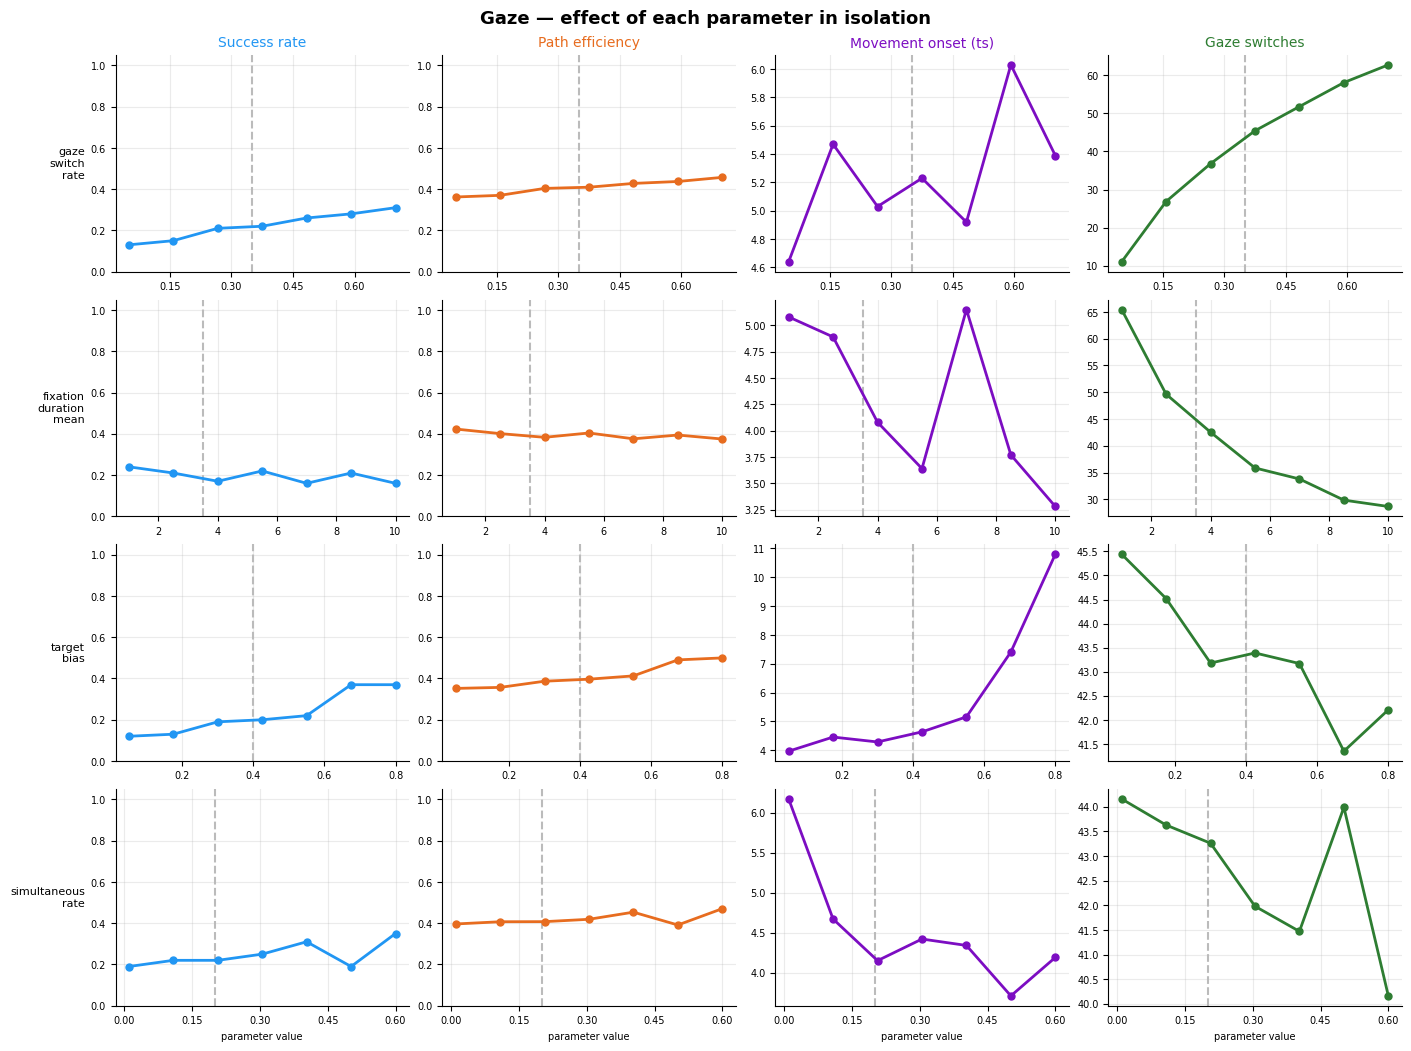

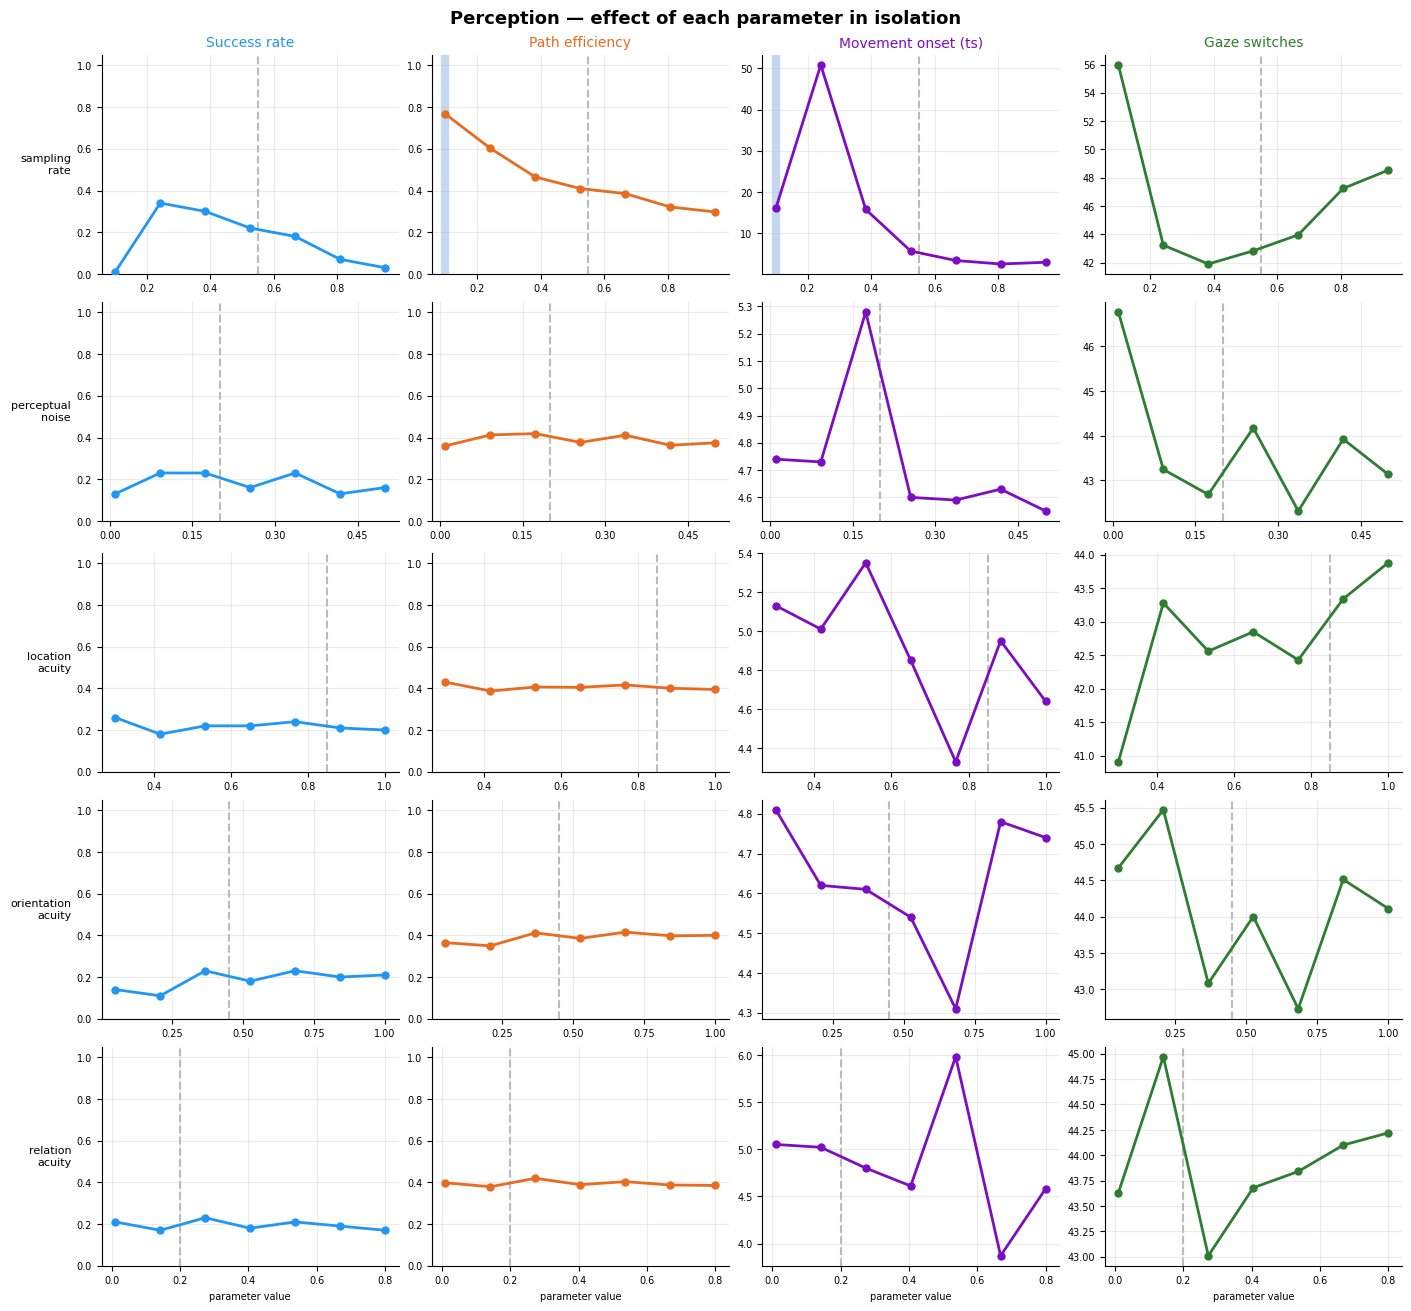

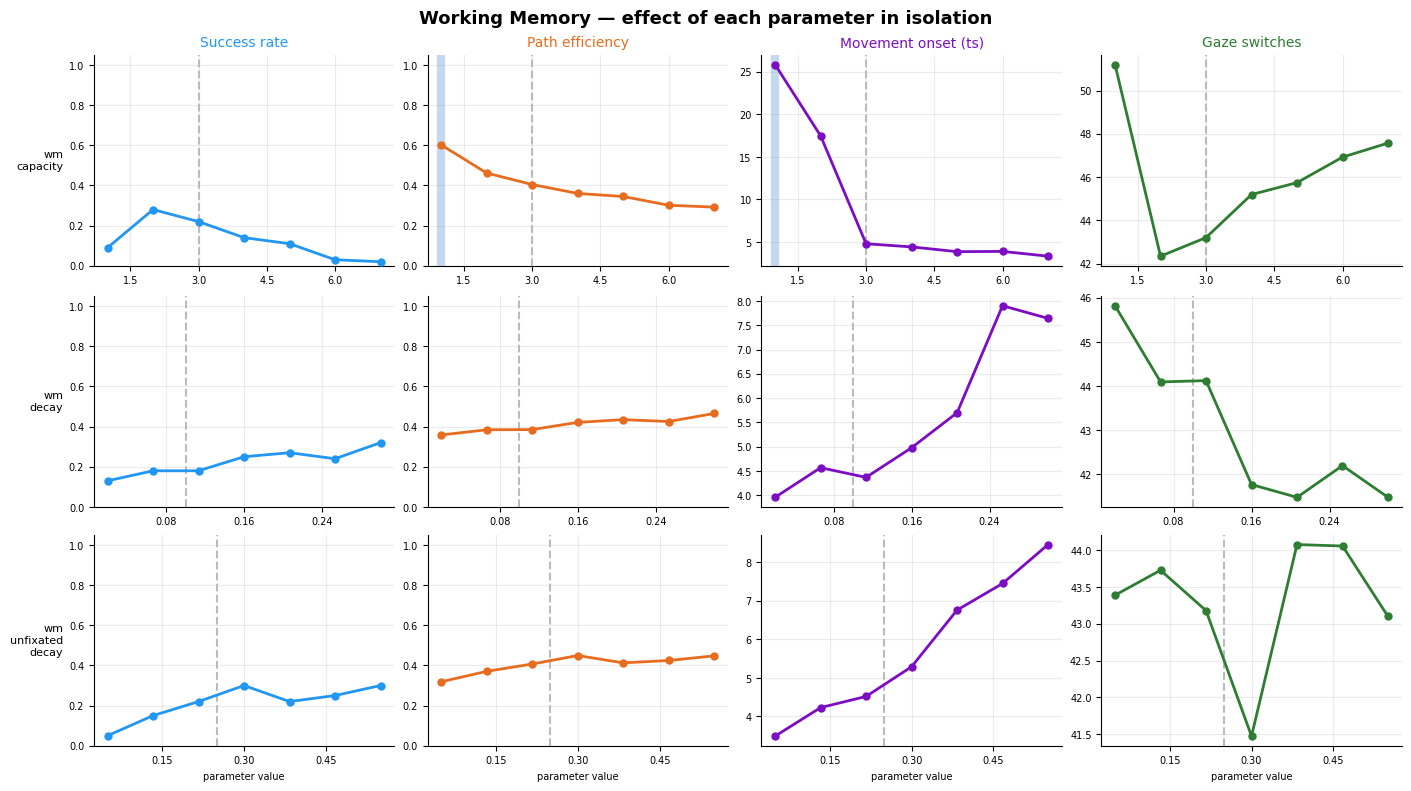

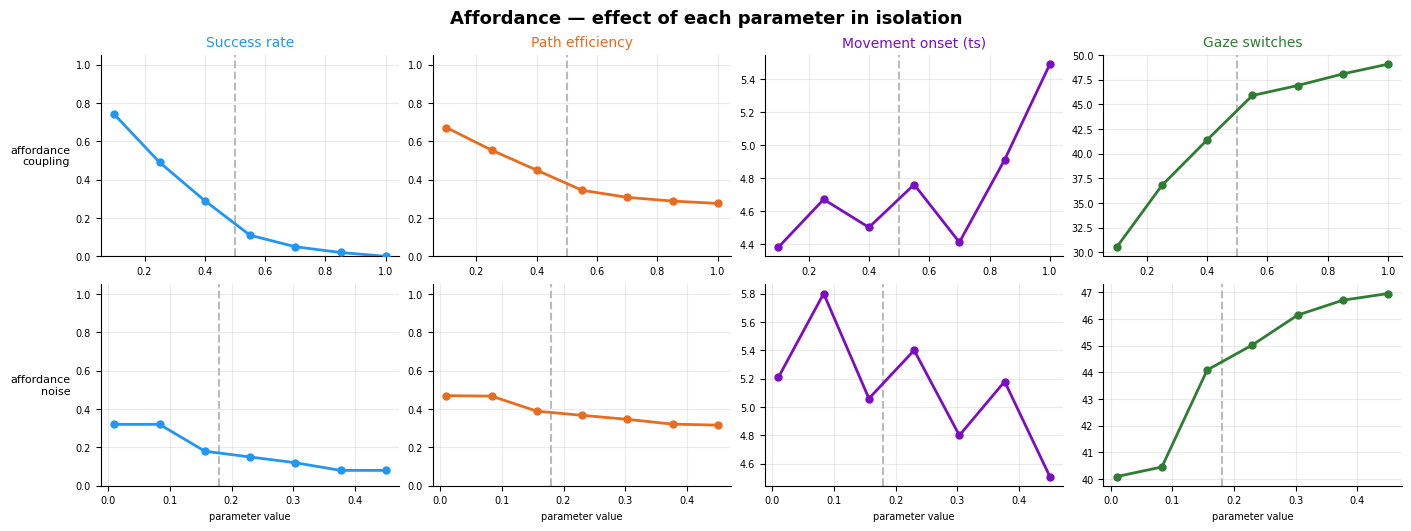

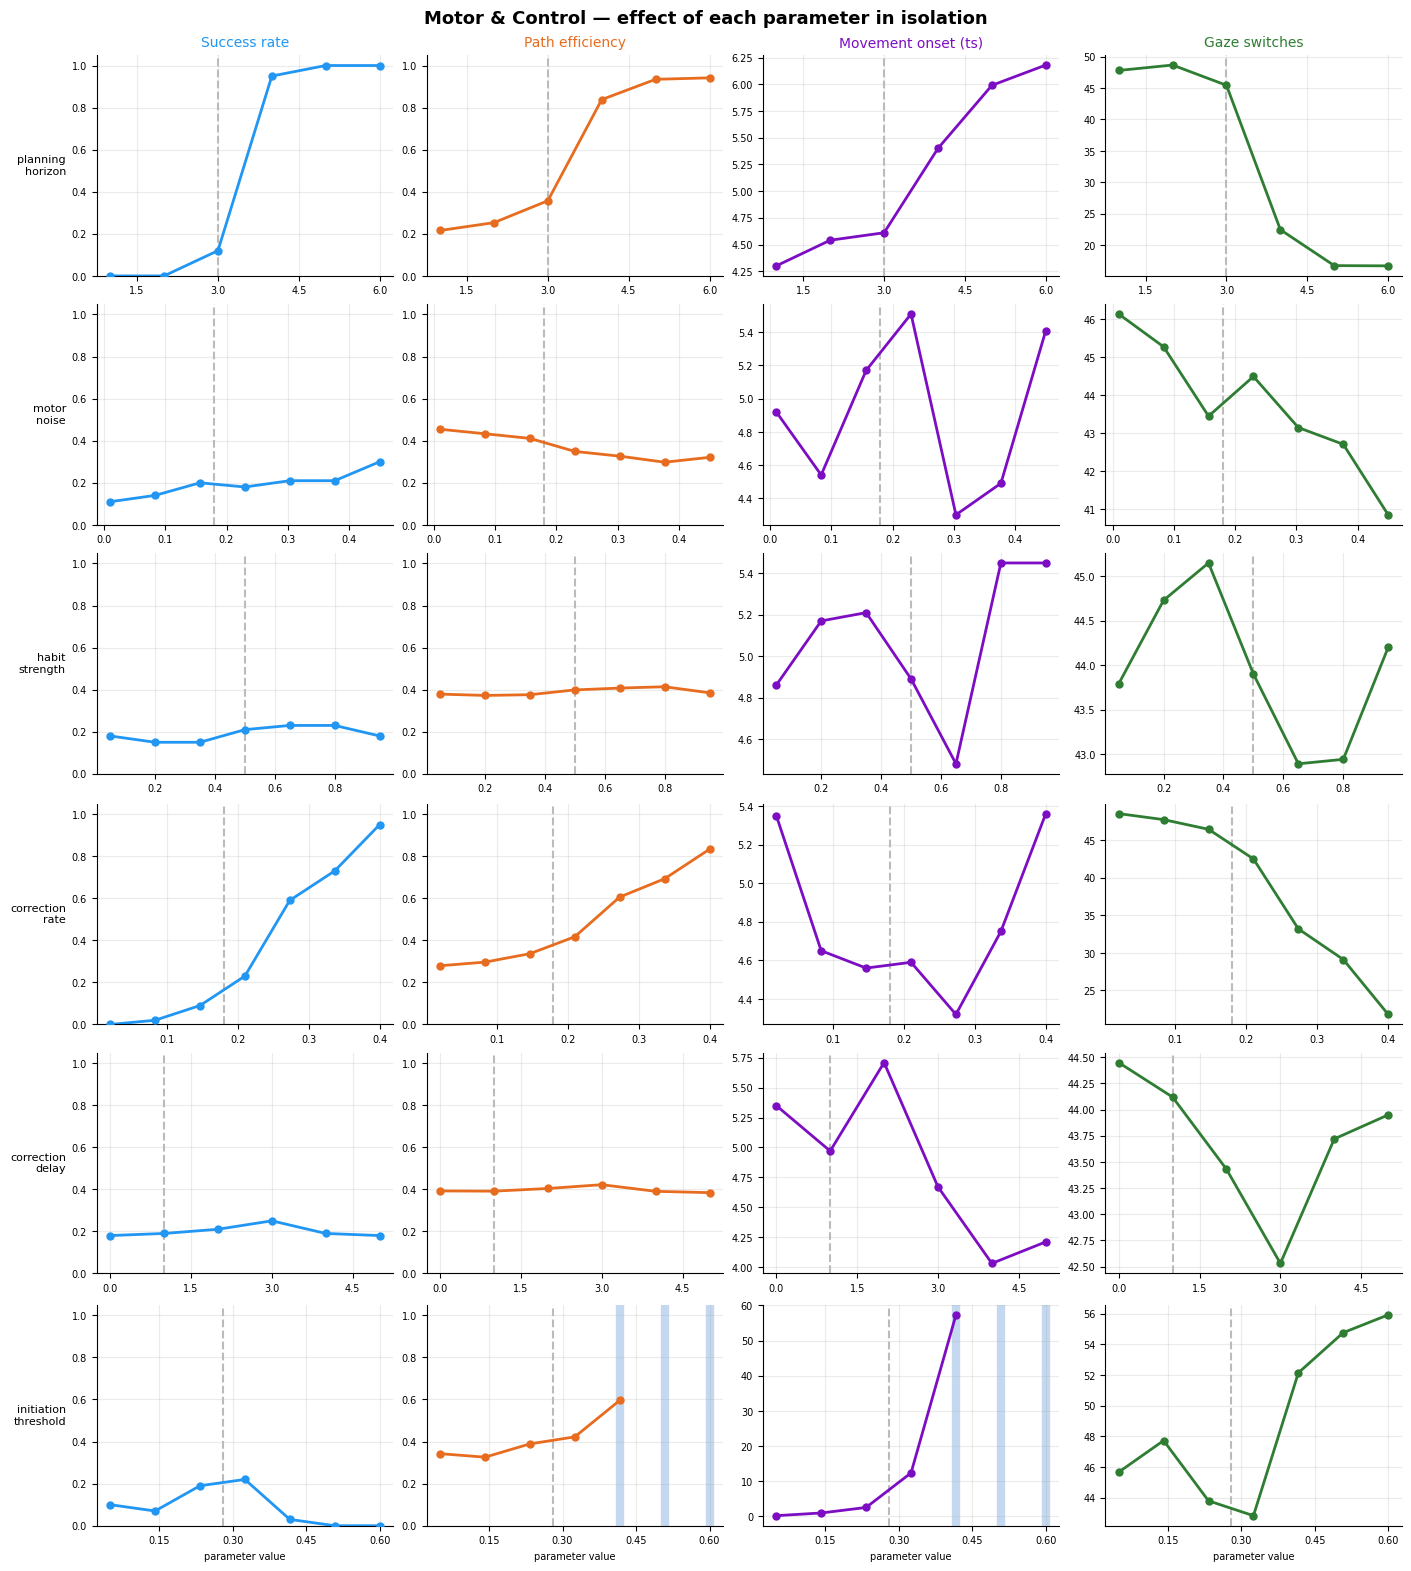

In [7]:
for group, parameters in PARAM_GROUPS.items():
    plots.plot_group_sweep(group, parameters, sweep_data, BASELINE).show()

## Which settings recover the task

Success proportions with Wilson intervals, reported in preference to completion
times.

In [ ]:
TOP_N = 6
header = "{:22s}{:>10s}{:>9s}{:>8s}{:>10s}{:>18s}{:>8s}".format(
    "parameter", "level", "value", "succ", "k/n", "95% CI", "time")
print(header)

for parameter in sorted_params[:TOP_N]:
    values = sorted(sweep_data[parameter])
    baseline_value = min(values, key=lambda candidate: abs(candidate - getattr(BASELINE, parameter)))

    for level, value in (("low", values[0]), ("baseline", baseline_value), ("high", values[-1])):
        row = sweep_data[parameter][value]
        counts = "{}/{}".format(row["successes"], row["n_trials"])
        interval = "[{:.2f}, {:.2f}]".format(row["success_ci_low"], row["success_ci_high"])

        print("{:22s}{:>10s}{:9.3f}{:8.2f}{:>10s}{:>18s}{:8.0f}".format(
            parameter, level, value, row["success_rate"], counts, interval, row["mean_timesteps"]))

parameter                  level    value    succ       k/n            95% CI    time
planning_horizon             low    1.000    0.00     0/100      [0.00, 0.04]     180
planning_horizon        baseline    3.000    0.12    12/100      [0.07, 0.20]     169
planning_horizon            high    6.000    1.00   100/100      [0.96, 1.00]      61
correction_rate              low    0.020    0.00     0/100      [0.00, 0.04]     180
correction_rate         baseline    0.210    0.23    23/100      [0.16, 0.32]     158
correction_rate             high    0.400    0.95    95/100      [0.89, 0.98]      81
initiation_threshold         low    0.050    0.10    10/100      [0.06, 0.17]     170
initiation_threshold    baseline    0.325    0.22    22/100      [0.15, 0.31]     160
initiation_threshold        high    0.600    0.00     0/100      [0.00, 0.04]     180
sampling_rate                low    0.100    0.01     1/100      [0.00, 0.05]     179
sampling_rate           baseline    0.525    0.22    2

## Stability of the ranking across baselines and tasks

The primary sweep gives one ranking. This shows how far that ranking is a
property of the model and how far it is a property of the baseline and task it
was computed on.

Pairwise agreement between rankings:
  Kendall tau across 36 pairs: median 0.63, range 0.46 to 0.85

Rank of each parameter across the nine baseline x task combinations:
  planning_horizon         mean rank   1.0  (best 1, worst 1)
  sampling_rate            mean rank   2.4  (best 2, worst 3)
  initiation_threshold     mean rank   3.8  (best 3, worst 5)
  wm_capacity              mean rank   5.2  (best 4, worst 7)
  correction_rate          mean rank   5.3  (best 2, worst 15)
  target_bias              mean rank   6.2  (best 5, worst 8)
  gaze_switch_rate         mean rank   7.1  (best 5, worst 10)
  motor_noise              mean rank   9.4  (best 6, worst 13)

Top three parameters under each design:
  immature|hard_balanced             planning_horizon, correction_rate, sampling_rate
  immature|translation_dominant      planning_horizon, correction_rate, sampling_rate
  immature|rotation_dominant         planning_horizon, sampling_rate, correction_rate
  mid|hard_balanced             

/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74898/1439907920.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_rank_stability(exp2["grid"], stability).show()


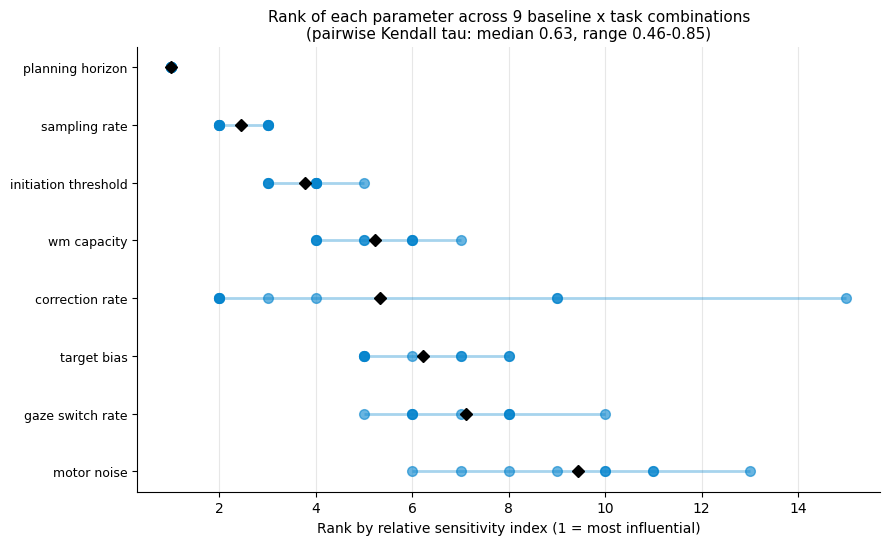

In [9]:
stability = exp2["rank_stability"]
plots.plot_rank_stability(exp2["grid"], stability).show()

print("Pairwise agreement between rankings:")
taus = []
for pair, values in stability["pairwise"].items():
    taus.append(values["kendall_tau"])
print(f"  Kendall tau across {len(taus)} pairs: median {np.median(taus):.2f}, "
      f"range {min(taus):.2f} to {max(taus):.2f}")

print("\nRank of each parameter across the nine baseline x task combinations:")
for parameter in sorted(stability["per_parameter"],
                        key=lambda name: stability["per_parameter"][name]["mean_rank"])[:8]:
    row = stability["per_parameter"][parameter]
    print(f"  {parameter:24s} mean rank {row['mean_rank']:5.1f}  "
          f"(best {row['min_rank']}, worst {row['max_rank']})")

print("\nTop three parameters under each design:")
for design, payload in exp2["grid"].items():
    print(f"  {design:34s} {', '.join(payload['order'][:3])}")

## Animation of the top parameters

In [ ]:
TOP_ANIM = sorted_params[:6]  # top 6 most influential (heatmap order)
LEVELS = ["Low", "Baseline", "High"]
ANIM_SEED = 123


def anim_values(param):
    """Return (lo, baseline_val, hi) for a parameter."""
    vals = sorted(SWEEP_CONFIG[param])
    return vals[0], getattr(BASELINE, param), vals[-1]


print(f"Running animation trials — 3 values × {len(TOP_ANIM)} parameters on hard task…")
anim_trials = {}
for param in TOP_ANIM:
    lo, base, hi = anim_values(param)
    anim_trials[param] = {}
    for lv, val in zip(LEVELS, [lo, base, hi]):
        kw = {param: val}
        if param == "habit_strength":
            kw["goal_directed_strength"] = round(1.0 - val, 4)
        p = replace(BASELINE, name=f"{param}={val:.3g}", **kw)
        anim_trials[param][lv] = run_trial(p, TASK, seed=ANIM_SEED)

print(f"\nDone — {len(TOP_ANIM) * 3} trials\n")
for param in TOP_ANIM:
    line = "  ".join(
        f"{lv}: {'OK' if anim_trials[param][lv].success else 'FAIL'}"
        f"(t={anim_trials[param][lv].timesteps_used})"
        for lv in LEVELS
    )
    print(f"  {param:<28s}  {line}")

Running animation trials — 3 values × 6 parameters on hard task…

Done — 18 trials

  planning_horizon              Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: OK(t=74)
  correction_rate               Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: OK(t=100)
  initiation_threshold          Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: FAIL(t=180)
  sampling_rate                 Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: FAIL(t=180)
  affordance_coupling           Low: OK(t=110)  Baseline: FAIL(t=180)  High: FAIL(t=180)
  wm_capacity                   Low: FAIL(t=180)  Baseline: FAIL(t=180)  High: FAIL(t=180)


In [ ]:
FPS = 12
ANIM_STEP = 3
TRIAL_HOLD = 22

LEVEL_COLOURS = {
    "Low": "#fb7185",
    "Baseline": "#6ee7b7",
    "High": "#60a5fa",
}

# Eye position, top-left corner of the workspace
EYE_X, EYE_Y = -0.09, 0.36

# Frame schedule: one segment per parameter
SCHEDULE = []
for p_idx, param in enumerate(TOP_ANIM):
    max_t = max(len(anim_trials[param][lv].trajectory) for lv in LEVELS)
    for t in list(range(0, max_t, ANIM_STEP)) + [max_t - 1]:
        SCHEDULE.append((p_idx, t, False))
    for _ in range(TRIAL_HOLD):
        SCHEDULE.append((p_idx, max_t - 1, True))

N_FRAMES = len(SCHEDULE)
print(f"{N_FRAMES} frames  (~{N_FRAMES / FPS:.0f}s at {FPS} fps)")

# Figure
fig = plt.figure(figsize=(13, 5.8), dpi=100, facecolor=am.BACKGROUND_COLOUR)
gs = GridSpec(
    2,
    4,
    height_ratios=[3, 2],
    width_ratios=[3, 3, 3, 2.2],
    hspace=0.06,
    wspace=0.07,
    left=0.02,
    right=0.99,
    top=0.87,
    bottom=0.05,
)
work_axes = [fig.add_subplot(gs[:, c]) for c in range(3)]  # span both rows
succ_ax = fig.add_subplot(gs[0, 3])
gaze_ax = fig.add_subplot(gs[1, 3])

param_title = fig.text(
    0.5,
    0.975,
    "",
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
    color=am.ACCENT_COLOUR,
    fontfamily="serif",
)
fig.text(
    0.5,
    0.928,
    f"Task: goal=({TASK.goal_x}, {TASK.goal_y}, {np.degrees(TASK.goal_angle):.0f}°)  "
    f"·  obj {TASK.obj_width:.2f}×{TASK.obj_height:.2f}  "
    f"·  max_t={TASK.max_timesteps}  ·  all other params at BASELINE",
    ha="center",
    va="top",
    fontsize=7.5,
    color=am.DIM_COLOUR,
)
timestep_txt = fig.text(0.5, 0.005, "", ha="center", fontsize=7, color=am.DIM_COLOUR)

# Static workspace setup
_xlim = (-0.15, TASK.goal_x + 0.18)
_ylim = (-TASK.goal_x * 0.52, TASK.goal_x * 0.52)

trails, status_txts, value_txts = {}, {}, {}

for c, lv in enumerate(LEVELS):
    ax = work_axes[c]
    colour = LEVEL_COLOURS[lv]

    ax.set_facecolor(am.SURFACE_COLOUR)
    ax.set_xlim(*_xlim)
    ax.set_ylim(*_ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(colors=am.DIM_COLOUR, labelsize=5)
    for sp in ax.spines.values():
        sp.set_color(am.BORDER_COLOUR)

    am.draw_rotated_rectangle(
        ax,
        TASK.goal_x,
        TASK.goal_y,
        TASK.obj_width + 0.04,
        TASK.obj_height + 0.04,
        TASK.goal_angle,
        am.GOAL_COLOUR,
        fc="none",
        lw=1.5,
        ls="--",
        alpha=0.4,
        z=1,
    )

    ax.set_title(lv, fontsize=11, color=colour, pad=4)

    (trail,) = ax.plot([], [], color=colour, alpha=0.45, lw=1.3, zorder=2)
    trails[c] = trail

    status_txts[c] = ax.text(
        0.97,
        0.05,
        "",
        transform=ax.transAxes,
        fontsize=7,
        ha="right",
        va="bottom",
        fontfamily="monospace",
        color=am.TEXT_COLOUR,
        zorder=15,
    )
    value_txts[c] = ax.text(
        0.03,
        0.96,
        "",
        transform=ax.transAxes,
        fontsize=7,
        ha="left",
        va="top",
        fontfamily="monospace",
        color=colour,
        zorder=15,
    )

# Right-column panels rebuilt whenever the parameter changes
_last_p = [-1]


def _refresh_panels(param):
    vals = sorted(sweep_data[param])
    y_succ = [sweep_data[param][v]["success_rate"] for v in vals]
    y_gsw = np.array([sweep_data[param][v]["mean_gaze_switches"] for v in vals])
    y_tfix = np.array([sweep_data[param][v]["mean_target_fixation"] for v in vals])
    y_ofix = np.array([sweep_data[param][v]["mean_object_fixation"] for v in vals])
    lo, base, hi = anim_values(param)

    # Normalise gaze switches to [0,1] to share the fixation-fraction axis
    gsw_max = float(y_gsw.max()) if y_gsw.max() > 0 else 1.0
    y_gsw_n = y_gsw / gsw_max

    # Success rate panel
    succ_ax.cla()
    succ_ax.set_facecolor(am.SURFACE_COLOUR)
    for sp in succ_ax.spines.values():
        sp.set_color(am.BORDER_COLOUR)
    succ_ax.plot(vals, y_succ, "-", color=am.DIM_COLOUR, lw=1.5, alpha=0.65)
    succ_ax.fill_between(vals, y_succ, alpha=0.07, color=am.DIM_COLOUR)
    for lv, val in zip(LEVELS, [lo, base, hi]):
        y_pt = float(np.interp(val, vals, y_succ))
        succ_ax.scatter(
            [val],
            [y_pt],
            color=LEVEL_COLOURS[lv],
            s=55,
            zorder=5,
            edgecolors=am.BACKGROUND_COLOUR,
            linewidths=1.5,
        )
    succ_ax.set_ylim(-0.05, 1.10)
    succ_ax.set_title("success rate", fontsize=7, color=am.TEXT_COLOUR, pad=2)
    succ_ax.set_ylabel("rate", fontsize=6, color=am.DIM_COLOUR)
    succ_ax.tick_params(colors=am.DIM_COLOUR, labelsize=5, labelbottom=False)
    succ_ax.grid(alpha=0.18, color=am.BORDER_COLOUR)

    # Gaze metrics panel
    gaze_ax.cla()
    gaze_ax.set_facecolor(am.SURFACE_COLOUR)
    for sp in gaze_ax.spines.values():
        sp.set_color(am.BORDER_COLOUR)
    gaze_ax.plot(
        vals,
        y_tfix,
        "--",
        color=am.GAZE_COLOUR_TARGET,
        lw=1.5,
        alpha=0.85,
        label="target fix %",
    )
    gaze_ax.plot(
        vals, y_ofix, ":", color="#94a3b8", lw=1.2, alpha=0.65, label="obj fix %"
    )
    gaze_ax.plot(
        vals,
        y_gsw_n,
        "-",
        color=am.GAZE_COLOUR_OBJECT,
        lw=1.5,
        alpha=0.85,
        label=f"switches÷{gsw_max:.0f}",
    )
    for lv, val in zip(LEVELS, [lo, base, hi]):
        gaze_ax.scatter(
            [val],
            [float(np.interp(val, vals, y_tfix))],
            color=LEVEL_COLOURS[lv],
            s=45,
            zorder=6,
            marker="^",
            edgecolors=am.BACKGROUND_COLOUR,
            linewidths=1.5,
        )
        gaze_ax.scatter(
            [val],
            [float(np.interp(val, vals, y_gsw_n))],
            color=LEVEL_COLOURS[lv],
            s=45,
            zorder=6,
            edgecolors=am.BACKGROUND_COLOUR,
            linewidths=1.5,
        )
    gaze_ax.set_ylim(-0.02, 1.08)
    gaze_ax.set_title("eye gaze", fontsize=7, color=am.TEXT_COLOUR, pad=2)
    gaze_ax.set_xlabel(param.replace("_", " "), fontsize=6, color=am.DIM_COLOUR)
    gaze_ax.set_ylabel("fraction / norm.", fontsize=6, color=am.DIM_COLOUR)
    gaze_ax.tick_params(colors=am.DIM_COLOUR, labelsize=5)
    gaze_ax.grid(alpha=0.18, color=am.BORDER_COLOUR)
    gaze_ax.legend(
        fontsize=5,
        loc="best",
        facecolor=am.SURFACE_COLOUR,
        edgecolor=am.BORDER_COLOUR,
        labelcolor=am.TEXT_COLOUR,
    )


# Animation update
def update(frame_idx):
    p_idx, t, is_hold = SCHEDULE[frame_idx]
    param = TOP_ANIM[p_idx]
    lo, base, hi = anim_values(param)

    if p_idx != _last_p[0]:
        _refresh_panels(param)
        _last_p[0] = p_idx
        for c in range(3):
            trails[c].set_data([], [])
            status_txts[c].set_text("")
        for ax in work_axes:
            am.remove_dynamic_artists(ax)

    param_title.set_text(
        f"Parameter: {param.replace('_', ' ')}  ·  [{p_idx + 1} / {len(TOP_ANIM)}]"
    )
    timestep_txt.set_text(f"t = {t}")

    for c, (lv, val) in enumerate(zip(LEVELS, [lo, base, hi])):
        ax = work_axes[c]
        trial = anim_trials[param][lv]
        traj = trial.trajectory
        t_c = min(t, len(traj) - 1)
        step = traj[t_c]
        colour = LEVEL_COLOURS[lv]

        am.remove_dynamic_artists(ax)

        trails[c].set_data(
            [s.obj_x for s in traj[: t_c + 1]],
            [s.obj_y for s in traj[: t_c + 1]],
        )

        am.mark_dynamic(
            am.draw_rotated_rectangle(
                ax,
                step.obj_x,
                step.obj_y,
                TASK.obj_width,
                TASK.obj_height,
                step.obj_angle,
                colour,
                alpha=0.88,
            )
        )

        # Gaze: eye circle + fixation target + connecting line
        looking_at_object = step.gaze_target == "object"
        gz_col = am.GAZE_COLOUR_OBJECT if looking_at_object else am.GAZE_COLOUR_TARGET
        fix_x = step.obj_x if looking_at_object else TASK.goal_x
        fix_y = step.obj_y if looking_at_object else TASK.goal_y

        for circle in (
            mpatches.Circle(
                (EYE_X, EYE_Y), 0.028, fc=gz_col, ec="none", alpha=0.85, zorder=10
            ),
            mpatches.Circle(
                (EYE_X, EYE_Y),
                0.012,
                fc=am.BACKGROUND_COLOUR,
                ec="none",
                alpha=0.90,
                zorder=11,
            ),
            mpatches.Circle(
                (fix_x, fix_y),
                0.022,
                fc=gz_col,
                ec="white",
                lw=0.4,
                alpha=0.70,
                zorder=8,
            ),
        ):
            ax.add_patch(am.mark_dynamic(circle))

        (gz_line,) = ax.plot(
            [EYE_X, fix_x],
            [EYE_Y, fix_y],
            color=gz_col,
            lw=0.9,
            alpha=0.40,
            zorder=5,
        )
        am.mark_dynamic(gz_line)
        am.mark_dynamic(
            ax.text(
                EYE_X + 0.055,
                EYE_Y,
                "obj" if looking_at_object else "tgt",
                fontsize=5,
                color=gz_col,
                va="center",
                fontfamily="monospace",
                alpha=0.85,
                zorder=12,
            )
        )

        value_txts[c].set_text(f"= {val:.3g}")

        done = t >= len(traj) - 1
        if done:
            status_txts[c].set_text("SUCCESS" if trial.success else "FAIL")
            status_txts[c].set_color(am.ACCENT_COLOUR if trial.success else "#fb7185")
        else:
            status_txts[c].set_text(f"err={step.pos_error:.2f}")
            status_txts[c].set_color(am.DIM_COLOUR)

    return []


anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=1000 / FPS, blit=False)
plt.close()
print(f"Animation built: {N_FRAMES} frames at {FPS} fps  (~{N_FRAMES / FPS:.0f}s)")

498 frames  (~42s at 12 fps)
Animation built: 498 frames at 12 fps  (~42s)


In [ ]:
_base = cwd if (cwd / "planning_cascade_model.py").exists() else cwd / "gaze_model"
mp4_path = _base / "param_sweep_animation.mp4"

writer = FFMpegWriter(
    fps=FPS,
    bitrate=2000,
    codec="h264",
    extra_args=["-pix_fmt", "yuv420p"],
)
anim.save(
    str(mp4_path),
    writer=writer,
    dpi=100,
    savefig_kwargs={"facecolor": am.BACKGROUND_COLOUR},
)
print(f"Saved: {mp4_path}")
print(f"File size: {mp4_path.stat().st_size / 1_000_000:.1f} MB")

Saved: /Users/katiesavva/action-planning/planning_model/param_sweep_animation.mp4
File size: 1.3 MB


## Gaze impact per parameter

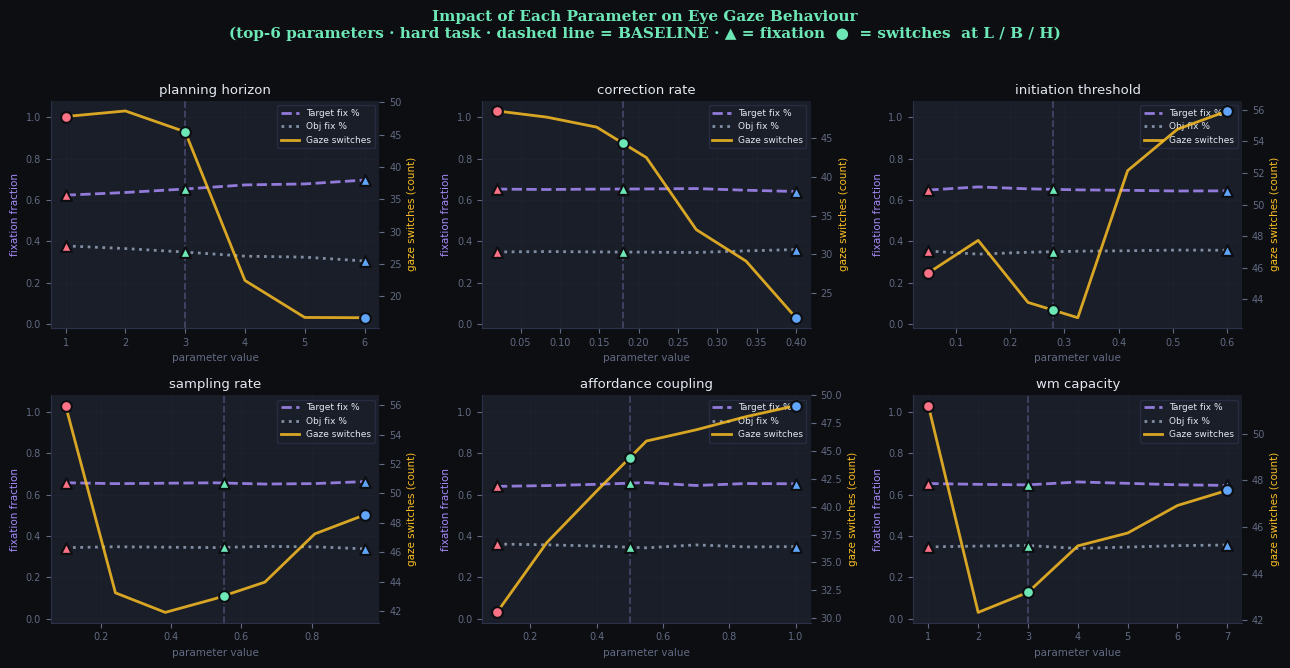

In [ ]:
# Left axis: target and object fixation fractions (0–1)
_FIX_METRICS = [
    ("mean_target_fixation", "Target fix %", am.GAZE_COLOUR_TARGET, "--"),
    ("mean_object_fixation", "Obj fix %", "#94a3b8", ":"),
]
# Right axis: raw gaze-switch count
_SW_METRIC = ("mean_gaze_switches", "Gaze switches", am.GAZE_COLOUR_OBJECT, "-")

fig, all_axes = plt.subplots(
    2,
    3,
    figsize=(13, 6.5),
    facecolor=am.BACKGROUND_COLOUR,
)
fig.patch.set_facecolor(am.BACKGROUND_COLOUR)

for idx, param in enumerate(TOP_ANIM):
    ax = all_axes.flat[idx]
    ax2 = ax.twinx()

    ax.set_facecolor(am.SURFACE_COLOUR)
    for sp in ax.spines.values():
        sp.set_color(am.BORDER_COLOUR)
    for sp in ax2.spines.values():
        sp.set_color(am.BORDER_COLOUR)

    vals = sorted(sweep_data[param])
    b_val = getattr(BASELINE, param)
    lo, base, hi = anim_values(param)

    # Left axis: fixation fractions
    for metric, label, colour, ls in _FIX_METRICS:
        y = [sweep_data[param][v][metric] for v in vals]
        ax.plot(vals, y, ls=ls, color=colour, lw=2.0, alpha=0.85, label=label)
        for lv, val in zip(LEVELS, [lo, base, hi]):
            ax.scatter(
                [val],
                [float(np.interp(val, vals, y))],
                color=LEVEL_COLOURS[lv],
                s=60,
                zorder=6,
                marker="^",
                edgecolors=am.BACKGROUND_COLOUR,
                linewidths=1.5,
            )

    # Right axis: gaze switches
    metric_sw, label_sw, colour_sw, ls_sw = _SW_METRIC
    y_sw = [sweep_data[param][v][metric_sw] for v in vals]
    ax2.plot(vals, y_sw, ls=ls_sw, color=colour_sw, lw=2.0, alpha=0.85, label=label_sw)
    for lv, val in zip(LEVELS, [lo, base, hi]):
        ax2.scatter(
            [val],
            [float(np.interp(val, vals, y_sw))],
            color=LEVEL_COLOURS[lv],
            s=60,
            zorder=6,
            edgecolors=am.BACKGROUND_COLOUR,
            linewidths=1.5,
        )

    ax.axvline(b_val, color="#444466", lw=1.3, ls="--", zorder=2)

    ax.set_ylim(-0.02, 1.08)
    ax.set_title(param.replace("_", " "), fontsize=9.5, color=am.TEXT_COLOUR, pad=5)
    ax.set_xlabel("parameter value", fontsize=7.5, color=am.DIM_COLOUR)
    ax.set_ylabel("fixation fraction", fontsize=7.5, color=am.GAZE_COLOUR_TARGET)
    ax2.set_ylabel("gaze switches (count)", fontsize=7.5, color=am.GAZE_COLOUR_OBJECT)
    ax.tick_params(colors=am.DIM_COLOUR, labelsize=7)
    ax2.tick_params(colors=am.DIM_COLOUR, labelsize=7)
    ax.grid(alpha=0.18, color=am.BORDER_COLOUR)

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(
        lines1 + lines2,
        labs1 + labs2,
        fontsize=6.5,
        loc="best",
        facecolor=am.SURFACE_COLOUR,
        edgecolor=am.BORDER_COLOUR,
        labelcolor=am.TEXT_COLOUR,
    )

fig.suptitle(
    "Impact of Each Parameter on Eye Gaze Behaviour\n"
    f"(top-{len(TOP_ANIM)} parameters · hard task · dashed line = BASELINE · "
    "▲ = fixation  ●  = switches  at L / B / H)",
    fontsize=11,
    fontweight="bold",
    color=am.ACCENT_COLOUR,
    fontfamily="serif",
    y=1.02,
)
plt.tight_layout()
plt.show()